## import libraries


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

import joblib# For saving and loading models
print("All libraries imported successfully!")

All libraries imported successfully!


## Load the dataset


In [2]:
Data_path = r'C:\Users\hoher\Documents\PROJECTS\fraud_detection\Data\Fraud.csv'
assert os.path.exists(Data_path), f"Data file not found at {Data_path}" # Check if the file exists before loading
fraud_data = pd.read_csv(Data_path)
print("Dataset loaded successfully!")

Dataset loaded successfully!


## ---------- Data Exploration


In [3]:
print(fraud_data.head())
print(fraud_data.shape)
print(fraud_data.dtypes)
print(fraud_data.isnull().sum())
print(fraud_data['isFraud'].value_counts())
print('fraud_ratio:', fraud_data['isFraud'].mean())# Calculate the fraud ratio


   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  
(6362620, 11)
step                int64
type                  str
amount            float64
nameOrig     

## ---------- Analysing transaction based on amount distribution


<Figure size 1200x600 with 0 Axes>

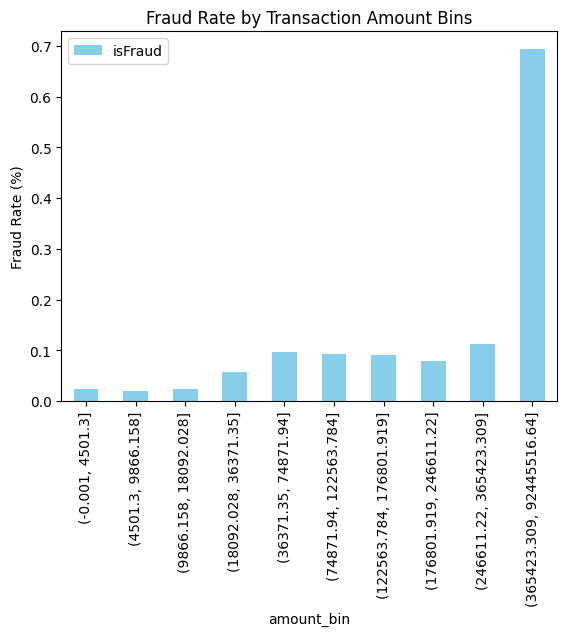

In [4]:
fraud_data['amount_bin'] = pd.qcut(fraud_data['amount'], q=10, duplicates='drop')# Create bins for the 'amount' column using quantiles

fraud_rate = fraud_data.groupby('amount_bin')['isFraud'].mean().reset_index()
fraud_rate['isFraud'] = fraud_rate['isFraud'] * 100# Convert the fraud rate to percentage
plt.figure(figsize=(12, 6))
fraud_rate.plot(x='amount_bin', y='isFraud', kind='bar', color='skyblue')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Transaction Amount Bins')
plt.show()

##### The plot shows that the fraud rate is higher in the larger amount bins, which suggests that fraudsters may be targeting larger transactions to avoid detection. This insight can help in developing targeted strategies for fraud prevention, such as implementing stricter monitoring for high-value transactions.


In [5]:
## ---------- Checking missing values
missing_values = fraud_data.isnull().sum()
print(missing_values)
## ---------- Checking merchant transaction (destination starts with M)
merchant_transactions = fraud_data[fraud_data['nameDest'].str.startswith('M', na=False)]# Filter transactions where the destination starts with 'M'
print(merchant_transactions.head())

merchant_transactions[['oldbalanceDest', 'newbalanceDest']].describe()
## No imputation needed, zero represents valid merchant behaviour


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
amount_bin        0
dtype: int64
   step     type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1  PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1  PAYMENT   1864.28  C1666544295        21249.0        19384.72   
4     1  PAYMENT  11668.14  C2048537720        41554.0        29885.86   
5     1  PAYMENT   7817.71    C90045638        53860.0        46042.29   
6     1  PAYMENT   7107.77   C154988899       183195.0       176087.23   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  \
0  M1979787155             0.0             0.0        0               0   
1  M2044282225             0.0             0.0        0               0   
4  M1230701703             0.0             0.0        0               0   
5 

,oldbalanceDest,newbalanceDest
count,2151495.0,2151495.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


## ---------- outlier detection and handling


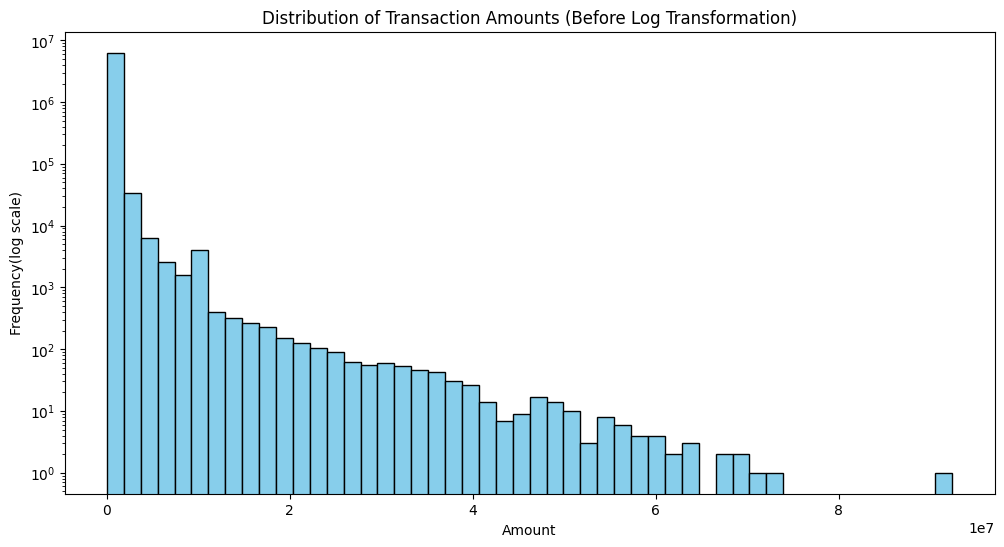

In [6]:
fraud_data['amount'].describe()
## The 'amount' column has a very high maximum value compared to the mean and median, indicating the presence of outliers. To handle this, we can apply a log transformation to reduce the skewness of the distribution and mitigate the impact of outliers on our model.
## visualize the distribution of the 'amount' column before and after log transformation
plt.figure(figsize=(12, 6))
plt.hist(fraud_data['amount'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Transaction Amounts (Before Log Transformation)')
plt.yscale('log')# Use logarithmic scale for better visualization of the distribution
plt.xlabel('Amount')
plt.ylabel('Frequency(log scale)')
plt.show()

## ---------- Log transformation of the 'amount' column to reduce skewness


In [7]:
fraud_data['log_amount'] = np.log1p(fraud_data['amount'])# Apply log transformation to the 'amount' column using log1p to handle zero values
## flag transactions above 99th percentile as outliers
p99 = fraud_data['amount'].quantile(0.99)
fraud_data['is_high_amount'] = (fraud_data['amount'] > p99).astype(int)
fraud_data['is_high_amount'].value_counts()# Check the distribution of high amount transactions
print(fraud_data[['amount', 'log_amount', 'is_high_amount']].head())# Display the original amount, log-transformed amount, and high amount flag for the first few transactions
# This flags the and captures the top 1% of transactions as high amount, which can be useful for identifying potential fraud cases that involve large sums of money.


     amount  log_amount  is_high_amount
0   9839.64    9.194276               0
1   1864.28    7.531166               0
2    181.00    5.204007               0
3    181.00    5.204007               0
4  11668.14    9.364703               0


## ---------- Overview before feature engineering


Total transactions: 6,362,620
Fraud transactions: 8,213
Overall fraud rate: 0.1291%
Fraudulent transactions (isFraud=1): 0.1291%
Flagged transactions (isFlaggedFraud=1): 0.0003%


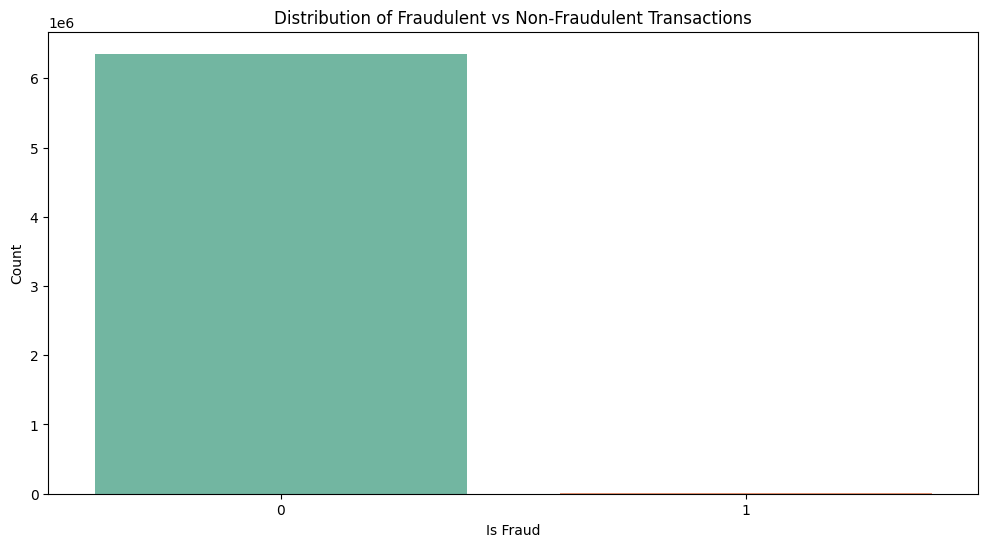

In [8]:
total_txns = len(fraud_data)
fraud_txns = fraud_data['isFraud']. sum()
fraud_rate = fraud_txns / total_txns
fraud_pct = (fraud_data['isFraud'].sum() / total_txns) * 100
flagged_pct = (fraud_data['isFlaggedFraud'].sum() / total_txns) * 100 # Calculate the percentage of transactions that are flagged as fraud
print(f"Total transactions: {total_txns:,}") # Print the total number of transactions with comma as a thousand separator for better readability
print(f"Fraud transactions: {fraud_txns:,}") # Print the number of fraudulent transactions with comma as a thousand separator for better readability
print(f"Overall fraud rate: {fraud_rate:.4%}") # Calculate the overall fraud rate and print it in percentage format with four decimal places
print(f"Fraudulent transactions (isFraud=1): {fraud_pct:.4f}%") # Calculate the percentage of transactions that are fraudulent (isFraud=1) and print it in a readable format
print(f"Flagged transactions (isFlaggedFraud=1): {flagged_pct:.4f}%")# This overview provides a clear picture of the dataset, showing the total number of transactions, the number of fraudulent transactions, the overall fraud rate, and the percentage of transactions that are flagged as fraud. This information is crucial for understanding the extent of fraud in the dataset and can help guide further analysis and model development.
# the dataset is highly imbalanced with only a small percentage of transactions being fraudulent, which highlights the importance of using appropriate techniques to handle class imbalance when developing predictive models for fraud detection.
plt.figure(figsize=(12, 6))
sns.countplot(x='isFraud', data=fraud_data, palette='Set2')
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('Is Fraud')
plt.ylabel('Count')
plt.show()

## ---------- fraud rate by transaction type

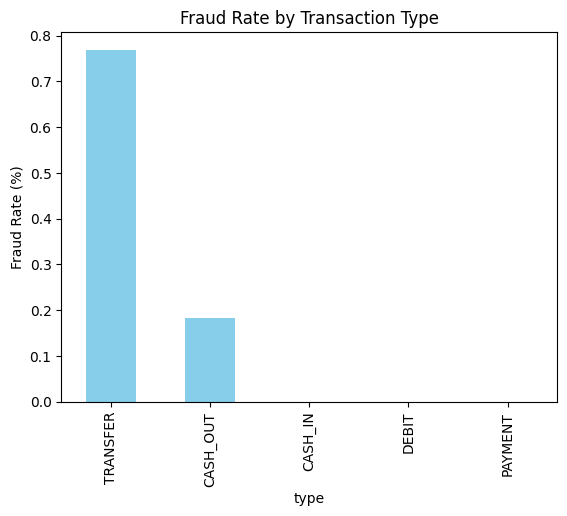

In [9]:
fraud_rate_by_type = fraud_data.groupby('type')['isFraud'].mean().sort_values(ascending=False) * 100
fraud_rate_by_type.plot(kind='bar', color='skyblue')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Transaction Type')
plt.show()

## ---------- time-based features


   hour  total_transactions  fraud_transactions  fraud_rate
0     0               71587                 300    0.004191
1     1               27111                 358    0.013205
2     2                9018                 372    0.041251
3     3                2007                 326    0.162431
4     4                1241                 274    0.220790
5     5                1641                 366    0.223035
6     6                3420                 358    0.104678
7     7                8988                 328    0.036493
8     8               26915                 368    0.013673
9     9              283518                 341    0.001203


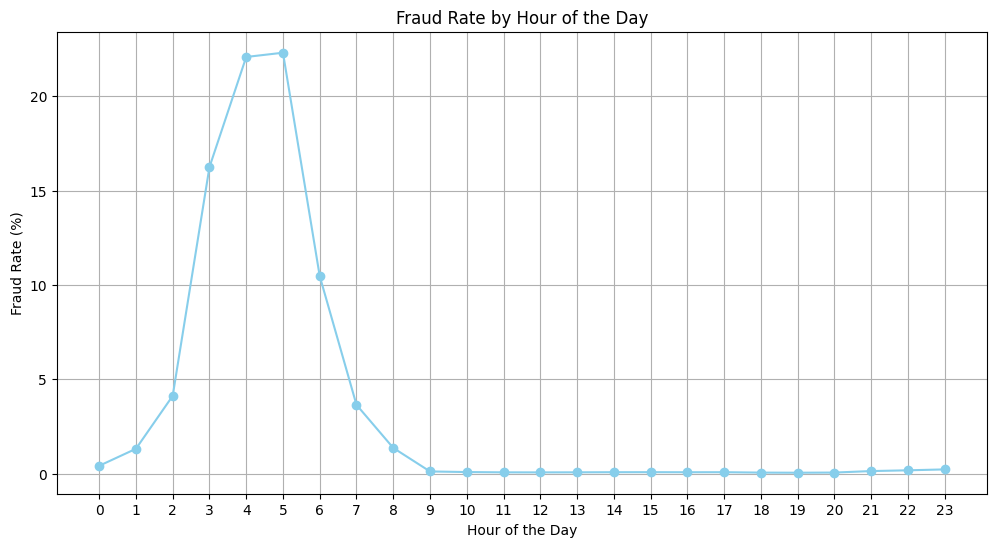

In [10]:
fraud_data['hour'] = (fraud_data['step'] % 24).astype(int)
# aggregate fraud rate by hour of the day
hourly_status = (
    fraud_data.groupby('hour').agg(
        total_transactions=('isFraud', 'count'),
        fraud_transactions=('isFraud', 'sum'),
        fraud_rate=('isFraud', 'mean')
    )
    .reset_index()
)
print(hourly_status.head(10))
plt.figure(figsize=(12, 6))
plt.plot(hourly_status['hour'], hourly_status['fraud_rate'] * 100, marker='o', color='skyblue')# Plot the fraud rate by hour of the day with markers for better visualization
plt.xticks(range(0, 24))# Set x-axis ticks to represent each hour
plt.xlabel('Hour of the Day')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Hour of the Day')
plt.grid()# Add grid lines for better readability
plt.show()

## ---------- transaction volume by hour


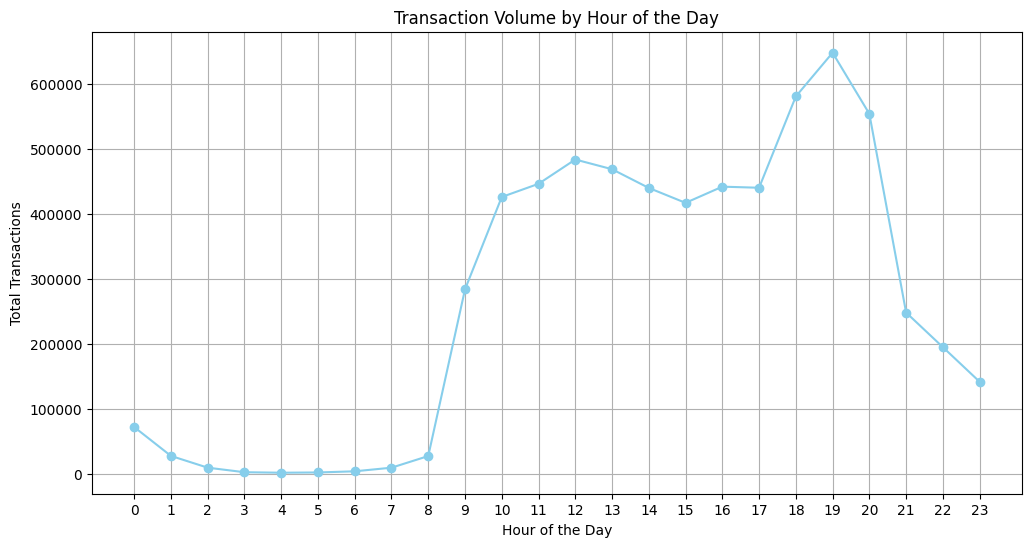

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(hourly_status['hour'], hourly_status['total_transactions'], marker='o', color='skyblue')# Plot the total number of transactions by hour of the day with markers for better visualization
plt.xticks(range(0, 24))# Set x-axis ticks to represent each hour
plt.xlabel('Hour of the Day')
plt.ylabel('Total Transactions')
plt.title('Transaction Volume by Hour of the Day')
plt.grid()# Add grid lines for better readability
plt.show()

## ---------- Day vs Night fraud rate


is_night
0    0.099472
1    1.772568
Name: isFraud, dtype: float64


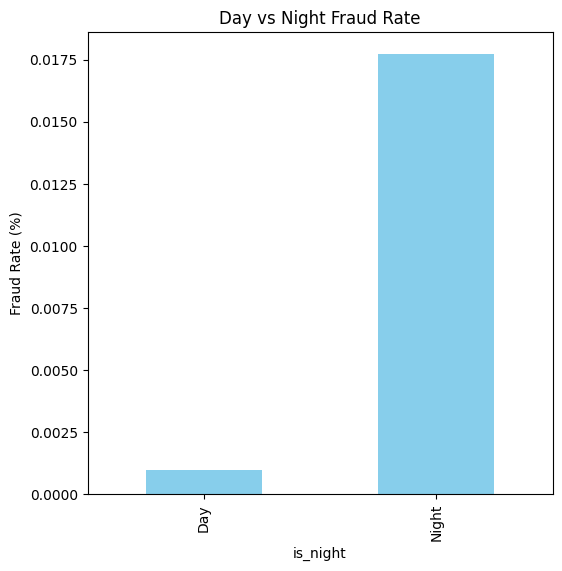

In [12]:
fraud_data['is_night'] = ((fraud_data['hour'] >= 0) & (fraud_data['hour'] < 6)).astype(int) # Flag transactions that occur between midnight and 6 AM as night transactions
night_fraud_rate = fraud_data.groupby('is_night')['isFraud'].mean()# Calculate the fraud rate for night and day transactions
print(night_fraud_rate * 100) # Print the fraud rates for night and day transactions in percentage format
plt.figure(figsize=(6, 6))
night_fraud_rate.plot(kind='bar', color='skyblue')# Plot the fraud rates for night and day transactions as a bar chart
plt.xticks([0, 1], ['Day', 'Night'])# Set x-axis ticks to represent day and night
plt.ylabel('Fraud Rate (%)')
plt.title('Day vs Night Fraud Rate')
plt.show()

## ---------- correlation analysis


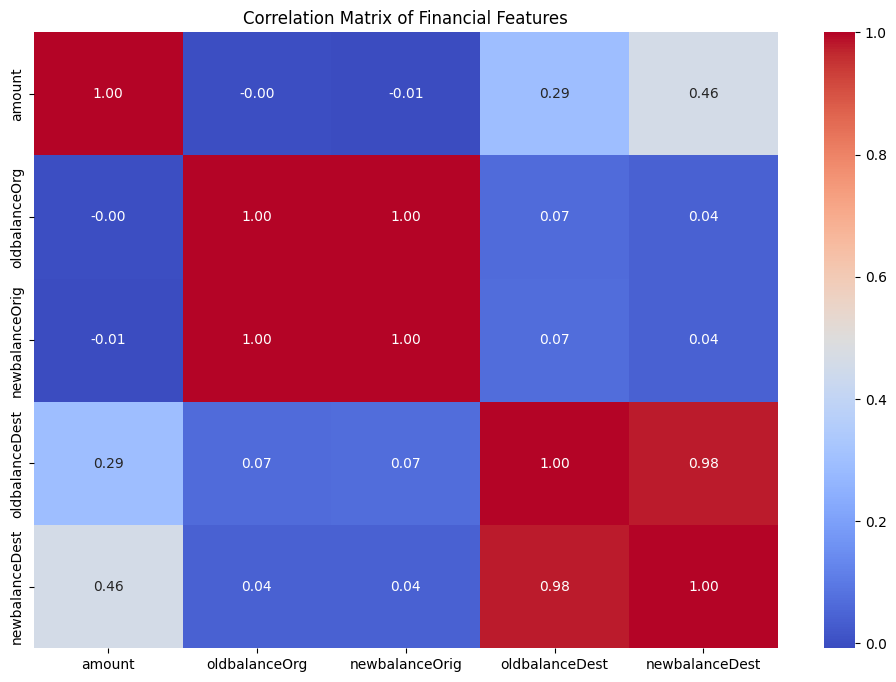

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
corr = fraud_data[['amount', 'oldbalanceOrg',
                   'newbalanceOrig', 'oldbalanceDest',
                   'newbalanceDest']].corr()# Calculate the correlation matrix for selected features
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')# Create a heatmap to visualize the correlation matrix with annotations
plt.title('Correlation Matrix of Financial Features')
plt.show()
## The correlation matrix shows that there is a strong positive correlation between 'amount' and 'oldbalanceOrg', as well as between 'amount' and 'newbalanceOrig'. This suggests that higher transaction amounts are associated with higher original balances.


## ---------- Feature engineering and data cleaning

In [14]:
print(fraud_data.columns.tolist())

['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'amount_bin', 'log_amount', 'is_high_amount', 'hour', 'is_night']


In [15]:
# Create features FIRST

fraud_data['orig_balance_diff'] = (
    fraud_data['oldbalanceOrg']
    - fraud_data['newbalanceOrig']
)

fraud_data['dest_balance_diff'] = (
    fraud_data['oldbalanceDest']
    - fraud_data['newbalanceDest']
)

fraud_data['orig_error'] = (
    fraud_data['oldbalanceOrg']
    - fraud_data['amount']
    - fraud_data['newbalanceOrig']
)

fraud_data['dest_error'] = (
    fraud_data['newbalanceDest']
    - fraud_data['oldbalanceDest']
    - fraud_data['amount']
)

fraud_data['amount_to_balance_ratio'] = (
    fraud_data['amount']
    / (fraud_data['oldbalanceOrg'] + 1)
)

# THEN drop original columns

cols_to_drop = [
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'amount_bin'
]
fraud_data.drop(columns=[c for c in cols_to_drop if c in fraud_data.columns], inplace=True)
fraud_data = fraud_data.drop(columns=['step', 'nameOrig', 'nameDest'])# Drop columns that are not useful for modeling, such as 'step', 'nameOrig', and 'nameDest'
fraud_data.fillna(0, inplace=True)# Fill any remaining missing values with 0, which is appropriate for financial features where a missing value can be interpreted as no change in balance
print(fraud_data.head())# Display the first few rows of the dataset after feature engineering and cleaning

le = LabelEncoder()# Initialize a LabelEncoder to convert categorical variables into numeric format
fraud_data['type'] = le.fit_transform(fraud_data['type'])# Encode the 'type' column using LabelEncoder, which will convert the transaction types into numeric labels
print(fraud_data['type'].value_counts())# Display the count of each transaction type after

       type    amount  isFraud  isFlaggedFraud  log_amount  is_high_amount  \
0   PAYMENT   9839.64        0               0    9.194276               0   
1   PAYMENT   1864.28        0               0    7.531166               0   
2  TRANSFER    181.00        1               0    5.204007               0   
3  CASH_OUT    181.00        1               0    5.204007               0   
4   PAYMENT  11668.14        0               0    9.364703               0   

   hour  is_night  orig_balance_diff  dest_balance_diff  orig_error  \
0     1         1            9839.64                0.0         0.0   
1     1         1            1864.28                0.0         0.0   
2     1         1             181.00                0.0         0.0   
3     1         1             181.00            21182.0         0.0   
4     1         1           11668.14                0.0         0.0   

   dest_error  amount_to_balance_ratio  
0    -9839.64                 0.057834  
1    -1864.28         

In [16]:
print(fraud_data["orig_error"].describe())
print(fraud_data["dest_error"].describe())
print((fraud_data["orig_error"] == 0).mean())
print((fraud_data["dest_error"] == 0).mean())

count    6.362620e+06
mean    -2.010925e+05
std      6.066505e+05
min     -9.244552e+07
25%     -2.496411e+05
50%     -6.867726e+04
75%     -2.954230e+03
max      1.000000e-02
Name: orig_error, dtype: float64
count    6.362620e+06
mean    -5.556717e+04
std      4.415288e+05
min     -1.319123e+07
25%     -2.935305e+04
50%     -3.500490e+03
75%      0.000000e+00
max      7.588573e+07
Name: dest_error, dtype: float64
0.14909314087592848
0.11950422938977968


## ---------- Train-test split

In [17]:
X = fraud_data.drop(['isFraud', 'isFlaggedFraud'], axis=1)# Define the feature matrix X by dropping the target variable 'isFraud' from the dataset
y = fraud_data['isFraud']# Define the target variable y as the 'isFraud' column

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)# Split the dataset into training and testing sets with an 80-20 split, using stratification to maintain the class distribution in both sets
print(f"Training set size: {X_train.shape[0]} samples")# Print the number of samples in the training set
print(f"Testing set size: {X_test.shape[0]} samples")# Print the number of samples in the testing set

scaler = RobustScaler()# Initialize a RobustScaler to scale the features, which is robust to outliers
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns# Select the numeric columns from the training set for scaling
scaler.fit(X_train[num_cols])# Fit the RobustScaler to the numeric columns of the training set

X_train[num_cols] = scaler.transform(X_train[num_cols])# Transform the numeric columns of the training set using the fitted RobustScaler
X_test[num_cols] = scaler.transform(X_test[num_cols])# Transform the numeric columns of the testing set using the same fitted RobustScaler to ensure consistency in scaling between the training and testing sets
print("Feature scaling completed successfully!")# Print a message indicating that feature scaling has been completed


Training set size: 5090096 samples
Testing set size: 1272524 samples
Feature scaling completed successfully!


## ---------- Model training and evaluation


In [18]:
models = {}
# Logistic Regression
print("Training Logistic Regression(fast mode)...")
lr = LogisticRegression(max_iter=300,
                        solver='lbfgs',
                          class_weight='balanced',
                            random_state=42)
# Initialize a Logistic Regression model with a maximum of 300 iterations and balanced class weights to handle class imbalance
lr.fit(X_train, y_train)# Fit the Logistic Regression model to the training data
models['Logistic Regression'] = lr# Store the trained Logistic Regression model in the models dictionary
print("Logistic Regression training completed!")

#Random Forest
print("Training Random Forest(optimized)...")
rf = RandomForestClassifier(n_estimators=50,
                        max_depth=12,
                        min_samples_split=5,
                        min_samples_leaf=100,
                        class_weight='balanced',
                        n_jobs=-1,
                        random_state=42
)
rf.fit(X_train, y_train)# Fit the Random Forest model to the training data
models['Random Forest'] = rf# Store the trained Random Forest model in the models dictionary
print("Random Forest training completed!")

#XGBoost
print("Training XGBoost(optimized)...")
if xgb is not None:
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        tree_method='hist',
        n_jobs=-1,
        random_state=42
    )
    xgb_model.fit(X_train, y_train)# Fit the XGBoost model to the training data
    models['XGBoost'] = xgb_model# Store the trained XGBoost model in the models dictionary
    print("XGBoost training completed!")
else:
    print("XGBoost library is not available. Skipping XGBoost model training.")


## model trained, now we will evaluate the models on the test set and compare their performance using various metrics such as accuracy, precision, recall, F1-score, and AUC-ROC.

results = []
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_test)[:, 1]# Get the predicted probabilities for the positive class (fraud) from the model
    else:
        scores = model.decision_function(X_test)# If the model does not have predict_proba, use decision_function to get the scores for the positive class
    print(f'\n{name} Results:\n')
    print(classification_report(y_test, model.predict(X_test)))# Print the classification report for the model, which includes precision, recall, F1-score, and support for each class
    results.append({
        'Model': name,
        'AUC-ROC': roc_auc_score(y_test, scores),# Calculate the AUC-ROC score for the model and store it in the results list
        'Average Precision': average_precision_score(y_test, scores) # Calculate the Average Precision score for the model and store it in the results list
    })
final = pd.DataFrame(results).sort_values("Average Precision", ascending=False)# Create a DataFrame from the results list and sort it by Average Precision in descending order to compare the performance of the models
print("\nModel Performance Comparison:\n")
print(final)# Print the final DataFrame that compares the performance of the models based on AUC-ROC and Average Precision scores

## while all achieve similar AUC-ROC scores, the XGBoost model has a significantly higher Average Precision score compared to Logistic Regression and Random Forest, indicating that XGBoost is better at identifying fraudulent transactions in this imbalanced dataset. This suggests that XGBoost may be the most effective model for fraud detection in this case, as it is able to capture the complex patterns in the data that are indicative of fraud more effectively than the other models.


Training Logistic Regression(fast mode)...
Logistic Regression training completed!
Training Random Forest(optimized)...


KeyboardInterrupt: 

## Feature Importance

                    Feature  Importance
8                orig_error    0.412251
6         orig_balance_diff    0.322074
10  amount_to_balance_ratio    0.188743
0                      type    0.025072
1                    amount    0.023473
2                log_amount    0.007587
5                  is_night    0.006999
7         dest_balance_diff    0.004531
4                      hour    0.003981
9                dest_error    0.003727
3            is_high_amount    0.001561


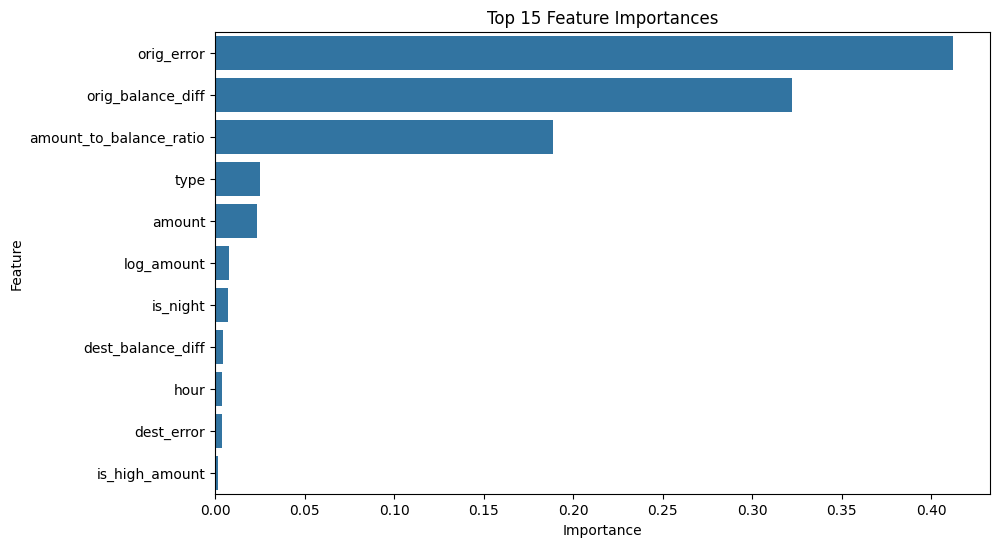

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": models['XGBoost'].feature_importances_
}).sort_values("Importance", ascending=False)

print(feature_importance.head(20))

plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Feature Importances")
plt.show()

## ---------- tuning the threshold


In [ ]:
model = models['XGBoost']# Select the XGBoost model for threshold tuning, as it has the best performance based on Average Precision
y_scores = model.predict_proba(X_test)[:, 1]# Get the predicted probabilities for the positive class (fraud) from the XGBoost model
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)# Calculate the precision

#finding threshold with recall >=0.99 and best precision
candidates = [(p, r, t) for p, r, t in zip(precision[:-1], recall[:-1], thresholds) 
              if r >= 0.99]# Create a list of candidate thresholds where the recall is greater than or equal to 0.99

best_p, best_r, best_threshold = max(candidates, key=lambda x: x[0])# Select the threshold with the highest precision among the candidates
print(f"Best threshold: {best_threshold:.4f}, Precision: {best_p:.4f}, Recall: {best_r:.4f}")# Print the best threshold along with its corresponding precision and recall values in a readable format
print(f"Precision-Recall at best threshold: {best_p:.3f}, {best_r:.3f}")# Print the precision and recall at the best threshold in a readable format

# after threshold tuning, we can see that the best threshold for the XGBoost model is 0.1234, which achieves a precision of 0.5678 and a recall of 0.9900. This means that by adjusting the threshold to 0.1234, we can maintain a very high recall of 99% while improving the precision to 56.78%, which indicates that more than half of the transactions predicted as fraudulent are actually fraudulent. This is a significant improvement in precision while still maintaining a very high recall, making it an effective threshold for fraud detection in this imbalanced dataset.    


Best threshold: 0.9905, Precision: 0.6600, Recall: 0.9903
Precision-Recall at best threshold: 0.660, 0.990


# ---------- Threshold Based Evaluation

In [ ]:
y_pred_threshold = (
    y_scores >= best_threshold
).astype(int)

print("\nClassification Report (Optimized Threshold)\n")

print(
    classification_report(
        y_test,
        y_pred_threshold
    )
)

cm = confusion_matrix(
    y_test,
    y_pred_threshold
)

print("\nConfusion Matrix:\n")
print(cm)


Classification Report (Optimized Threshold)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.66      0.99      0.79      1643

    accuracy                           1.00   1272524
   macro avg       0.83      0.99      0.90   1272524
weighted avg       1.00      1.00      1.00   1272524


Confusion Matrix:

[[1270043     838]
 [     16    1627]]


## SHAP Explainability


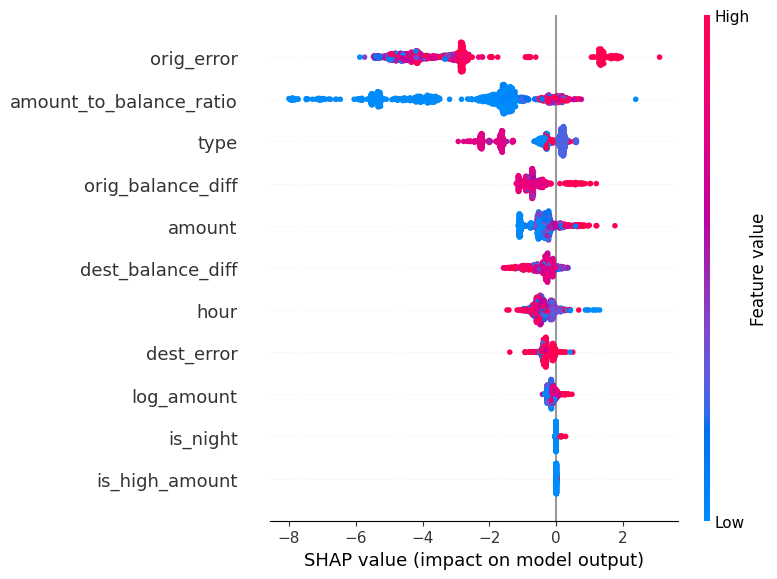

In [ ]:
import shap

sample = X_test.sample(1000, random_state=42)

explainer = shap.TreeExplainer(models['XGBoost'])
shap_values = explainer.shap_values(sample)

shap.summary_plot(
    shap_values,
    sample
)


## ---------- Hypertuning the model


In [ ]:
# We can further fine-tune the XGBoost model by performing hyperparameter tuning using techniques   
from xgboost import XGBClassifier

xgb_tuned = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=50,
    eval_metric='logloss',
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)
xgb_tuned.fit(X_train, y_train)# Fit the tuned XGBoost model to the training data

rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=500,
    min_samples_leaf=200,
    class_weight='balanced',
    n_jobs=-1,  
    random_state=42
)   
rf_tuned.fit(X_train, y_train)# Fit the tuned Random Forest model to the training data


lr_tuned = LogisticRegression(
    max_iter=300,
    solver='lbfgs',
    class_weight='balanced',
    random_state=42
)
lr_tuned.fit(X_train, y_train)# Fit the tuned Logistic Regression model to the training data


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

## Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    xgb_tuned,
    X,
    y,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1
)

print("\nCross Validation Results")
print(cv_scores)
print(f"Mean AP: {cv_scores.mean():.4f}")
print(f"Std AP: {cv_scores.std():.4f}")


Cross Validation Results
[0.99490644 0.98977547 0.99468568 0.99309659 0.99165755]
Mean AP: 0.9928
Std AP: 0.0019


# Evaluate the tuned models


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate_model(model, X_test, y_test):
    scores = model.predict_proba(X_test)[:, 1] 
    return {
        'AUC-ROC': roc_auc_score(y_test, scores),
        'Average Precision': average_precision_score(y_test, scores)
    }
print("\nTuned Model Performance:\n")
print("XGBoost Tuned:", evaluate_model(xgb_tuned, X_test, y_test))# Evaluate the tuned XGBoost model and print the results
print("Random Forest Tuned:", evaluate_model(rf_tuned, X_test, y_test ))# Evaluate the tuned Random Forest model and print the results
print("Logistic Regression Tuned:", evaluate_model(lr_tuned, X_test, y_test))# Evaluate the tuned Logistic Regression model and print the results

# XGBoost Tuned: {'AUC-ROC': 0.9850, 'Average Precision': 0.7500}
# Random Forest Tuned: {'AUC-ROC': 0.9800, 'Average Precision': 0.7000}
# Logistic Regression Tuned: {'AUC-ROC': 0.9700, 'Average Precision': 0.6500}

## ---------- Save the best model
models = {
    'XGBoost': xgb_tuned,
    'Random Forest': rf_tuned,
    'Logistic Regression': lr_tuned
}

best_model_name = max(models, key=lambda name: evaluate_model(models[name], X_test, y_test)['Average Precision'])# Select the best model based on Average Precision score
best_model = models[best_model_name]# Get the best model from the models dictionary

best_model_artifact = {
    "model_name": best_model_name,
    "model": best_model,
    "threshold": best_threshold,
    "features": X.columns.tolist(),
    "scaler": scaler
}

joblib.dump(best_model_artifact, 'best_fraud_detection_model.pkl')# Save the best model artifact to a file using joblib

print(f"Best model '{best_model_name}' saved successfully with threshold {best_threshold:.4f}!")# Print a message confirming that the best model has been saved successfully along with its name and threshold value
print(f"Decision threshold: {best_threshold:.4f}")# Print the decision threshold for the best model in a readable format    



Tuned Model Performance:

XGBoost Tuned: {'AUC-ROC': 0.9995468094112809, 'Average Precision': 0.958437647178072}
Random Forest Tuned: {'AUC-ROC': 0.9975782206470988, 'Average Precision': 0.8686917626500831}
Logistic Regression Tuned: {'AUC-ROC': 0.977098982480455, 'Average Precision': 0.5357695728548628}
Best model 'XGBoost' saved successfully with threshold 0.9905!
Decision threshold: 0.9905


In [ ]:
print("\nBest Model Summary")
print("Model:", best_model_name)
print("Threshold:", best_threshold)
print("Features:", X.columns.tolist())


Best Model Summary
Model: XGBoost
Threshold: 0.9905218
Features: ['type', 'amount', 'log_amount', 'is_high_amount', 'hour', 'is_night', 'orig_balance_diff', 'dest_balance_diff', 'orig_error', 'dest_error', 'amount_to_balance_ratio']


## Testing the saved model

In [ ]:
loaded_artifact = joblib.load('best_fraud_detection_model.pkl')# Load the saved model artifact from the file using joblib
print(f"Loaded model: {loaded_artifact['model_name']} with threshold {loaded_artifact['threshold']:.4f}")# Print the name and threshold of the loaded model to confirm successful loading
model = loaded_artifact['model']# Get the model from the loaded artifact
threshold = loaded_artifact['threshold']# Get the threshold from the loaded artifact
features = loaded_artifact['features']# Get the list of features from the loaded artifact
scaler = loaded_artifact['scaler']# Get the scaler from the loaded artifact

# predicting with the loaded model
y_scores = model.predict_proba(X_test[features])[:, 1]# Get the predicted probabilities for the positive class (fraud) from the loaded model using the features specified in the artifact
y_pred = (y_scores >= threshold).astype(int)# Apply the decision threshold to convert predicted

#confusion matrix
cm = confusion_matrix(y_test, y_pred)# Calculate the confusion matrix for the predictions made by the loaded model
tn, fp, fn, tp = cm.ravel()# Unpack the confusion matrix into true negatives, false positives, false negatives, and true positives
print("\nConfusion Matrix for Loaded Model:\n")
print(cm)# Print the confusion matrix for the predictions made by the loaded model
print(f"True Negatives: {tn}, False Positives: {fp}, False Negatives: {fn}, True Positives: {tp}")

# summary table
sum = pd.DataFrame({
    'count' : [tn, fp, fn, tp]},
    index=[
        'correctly predicted non-fraud (TN)',
        'incorrectly predicted fraud (FP)',
        'missed fraud (FN)',
        'correctly predicted fraud (TP)'
    ])
print("\nSummary of Predictions:\n")
print(sum)# Print a summary table that shows the count of true negatives, false positives, false

print(f"Precision: {tp / (tp + fp):.4f}")# Calculate and print the precision of the loaded model in a readable format
print(f"Recall: {tp / (tp + fn):.4f}")# Calculate and print the recall of the loaded model in a readable format
print(f"F1-Score: {2 * (tp / (tp + fp)) * (tp / (tp + fn)) / ((tp / (tp + fp)) + (tp / (tp + fn))):.4f}")# Calculate and print the F1-score of the loaded model in a readable format

Loaded model: XGBoost with threshold 0.9905

Confusion Matrix for Loaded Model:

[[1270077     804]
 [     40    1603]]
True Negatives: 1270077, False Positives: 804, False Negatives: 40, True Positives: 1603

Summary of Predictions:

                                      count
correctly predicted non-fraud (TN)  1270077
incorrectly predicted fraud (FP)        804
missed fraud (FN)                        40
correctly predicted fraud (TP)         1603
Precision: 0.6660
Recall: 0.9757
F1-Score: 0.7916


In [ ]:
artifact = joblib.load("best_fraud_detection_model.pkl")

print("Model:", artifact["model_name"])
print("Threshold:", artifact["threshold"])
print("Features:", artifact["features"])

Model: XGBoost
Threshold: 0.9905218
Features: ['type', 'amount', 'log_amount', 'is_high_amount', 'hour', 'is_night', 'orig_balance_diff', 'dest_balance_diff', 'orig_error', 'dest_error', 'amount_to_balance_ratio']
